In [18]:
from datetime import datetime
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

# Below are manually extracted times

In [6]:
#80 users
dict_80_users = {
    'registration_data': [
        "10:31:17.799741 - 10:31:19.956047 - 10:31:22.509365",
        "10:31:43.129430 - 10:31:45.516039 - 10:31:47.904954",
        "10:31:54.538818 - 10:31:56.255817 - 10:31:58.940568"
    ],
    'verification_times': ['0.42', '0.43', '0.46', '0.45', '0.49', '0.42', '0.45', '0.47', '0.44', '0.48'],
    'identification_times': ['0.47', '0.50', '0.50', '0.54', '0.47', '0.73', '0.47', '0.51', '0.51', '0.42']
}

#200 users
dict_200_users = {
    'registration_data': [
        "10:45:11.385584 - 10:45:12.830875 - 10:45:15.147503",
        "10:45:22.151814 - 10:45:23.915682 - 10:45:29.177213",
        "10:45:31.751316 - 10:45:33.232318 - 10:45:35.975279"
    ],
    'verification_times': ['0.38', '0.47', '0.56', '0.46', '0.51', '0.53', '0.45', '0.50', '0.42', '0.50'],
    'identification_times': ['0.38', '0.44', '0.44', '0.53', '0.44', '0.51', '0.49', '0.51', '0.51', '0.50']
}

#500 users
dict_500_users = {
    'registration_data': [
        "10:56:14.463215 - 10:56:15.862548 - 10:56:18.407350",
        "10:56:22.677770 - 10:56:24.033342 - 10:56:26.581399",
        "10:56:42.905241 - 10:56:44.735722 - 10:56:47.229020",
    ],
    'verification_times': ['0.46', '0.44', '0.50', '0.43', '0.53', '0.53', '0.52', '0.54', '0.52', '0.52'],
    'identification_times': ['0.44', '0.77', '0.53', '0.51', '0.55', '0.56', '0.46', '0.49', '0.54', '0.55']
}

#2750 users
dict_2750_users = {
    'registration_data': [
        "11:25:57.794247 - 11:25:59.593279 - 11:26:01.931606",
        "11:26:05.412844 - 11:26:07.258067 - 11:26:09.721750",
        "11:26:14.680963 - 11:26:16.488161 - 11:26:18.878170"
    ],
    'verification_times': ['0.45', '0.44', '0.55', '0.42', '0.59', '0.50', '0.41', '0.46', '0.58', '0.48'],
    'identification_times': ['0.95', '0.55', '0.56', '0.63', '0.65', '0.65', '0.61', '0.67', '0.61', '0.62']
}

#5000 users
dict_5000_users = {
    'registration_data': [
        "12:05:27.728789 - 12:05:29.434987 - 12:05:32.002448",
        "12:05:35.930841 - 12:05:37.675609 - 12:05:40.158666",
        "12:05:42.661497 - 12:05:44.214787 - 12:05:46.671548",
    ],
    'verification_times': ['0.44', '0.45', '0.43', '0.43', '0.47', '0.46', '0.47', '0.55', '0.63', '0.45'],
    'identification_times': ['0.58', '0.71', '0.75', '0.60', '0.61', '0.62', '0.64', '0.68', '0.70', '0.58']
}

In [8]:
def average_durations(lines):
    fmt = "%H:%M:%S.%f"
    
    ab_durations = []
    bc_durations = []
    
    for line in lines:
        a_str, b_str, c_str = [x.strip() for x in line.split(" - ")]
        
        a = datetime.strptime(a_str, fmt)
        b = datetime.strptime(b_str, fmt)
        c = datetime.strptime(c_str, fmt)
        
        ab_durations.append((b - a).total_seconds())
        bc_durations.append((c - b).total_seconds())
    
    avg_ab = sum(ab_durations) / len(ab_durations)
    avg_bc = sum(bc_durations) / len(bc_durations)
    
    return avg_ab, avg_bc

In [9]:
test_dicts = {
    80: dict_80_users, 
    200: dict_200_users, 
    500: dict_500_users, 
    2750: dict_2750_users, 
    5000: dict_5000_users
}

In [21]:
for test_dict in test_dicts.values():
    test_dict['verification_times'] = [float(n) for n in test_dict['verification_times']]
    test_dict['identification_times'] = [float(n) for n in test_dict['identification_times']]

In [22]:
for test_dict in test_dicts.values():
    avg_photos_time, avg_registration_time = average_durations(test_dict['registration_data'])
    test_dict['avg_photos_time'] = avg_photos_time
    test_dict['avg_registration_time'] = avg_registration_time
    print(avg_photos_time, avg_registration_time)

2.086638 2.542328
1.5633869999999999 3.4403733333333335
1.528462 2.528719
1.817151 2.397339666666667
1.6680853333333332 2.5024263333333336


In [23]:
for test_dict in test_dicts.values():
    mean_verification_time = statistics.mean(test_dict['verification_times'])
    mean_identification_time = statistics.mean(test_dict['identification_times'])
    test_dict['mean_verification_time'] = mean_verification_time
    test_dict['mean_identification_time'] = mean_identification_time
    print(mean_verification_time, mean_identification_time)

0.451 0.512
0.478 0.475
0.499 0.54
0.488 0.65
0.478 0.647


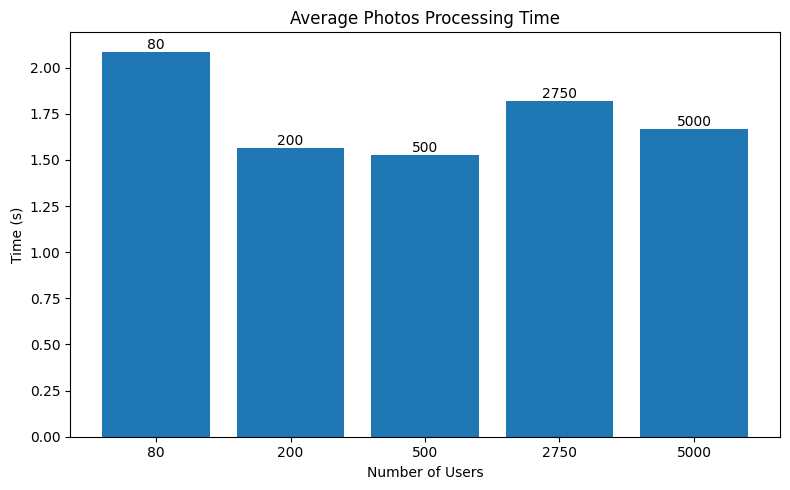

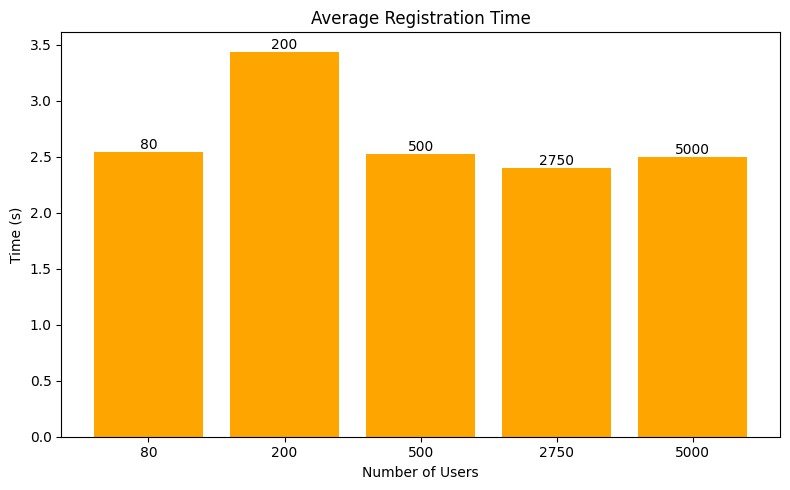

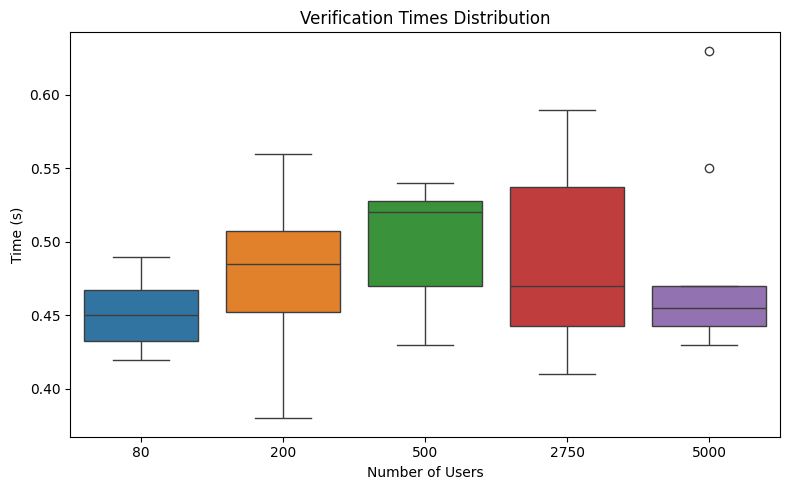

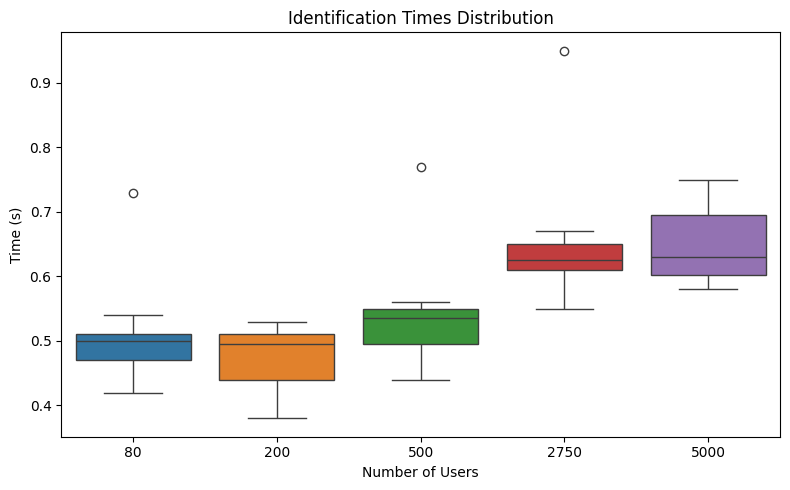

In [26]:
def plot_metrics(test_dicts):
    # Sort keys (user counts) for consistent ordering
    user_counts = sorted(test_dicts.keys())
    
    avg_photos = [test_dicts[k]["avg_photos_time"] for k in user_counts]
    avg_registration = [test_dicts[k]["avg_registration_time"] for k in user_counts]
    
    verification_data = [test_dicts[k]["verification_times"] for k in user_counts]
    identification_data = [test_dicts[k]["identification_times"] for k in user_counts]

    x = range(len(user_counts))  # categorical positions

    # ---- Bar plot: avg_photos_time ----
    plt.figure(figsize=(8, 5))
    bars = plt.bar(x, avg_photos)
    
    plt.xticks(x, user_counts)  # show user counts as labels
    plt.title("Average Photos Processing Time")
    plt.xlabel("Number of Users")
    plt.ylabel("Time (s)")
    
    # annotate values on bars
    for i, bar in enumerate(bars):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{user_counts[i]}",
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    plt.show()
    
    # ---- Bar plot: avg_registration_time ----
    plt.figure(figsize=(8, 5))
    bars = plt.bar(x, avg_registration, color="orange")
    
    plt.xticks(x, user_counts)
    plt.title("Average Registration Time")
    plt.xlabel("Number of Users")
    plt.ylabel("Time (s)")
    
    for i, bar in enumerate(bars):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{user_counts[i]}",
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    plt.show()

    # ---- Boxplot: verification_times ----
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=verification_data)
    plt.title("Verification Times Distribution")
    plt.xlabel("Number of Users")
    plt.ylabel("Time (s)")
    plt.xticks(range(len(user_counts)), user_counts)
    plt.tight_layout()
    plt.show()

    # ---- Boxplot: identification_times ----
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=identification_data)
    plt.title("Identification Times Distribution")
    plt.xlabel("Number of Users")
    plt.ylabel("Time (s)")
    plt.xticks(range(len(user_counts)), user_counts)
    plt.tight_layout()
    plt.show()

plot_metrics(test_dicts)